# 03 · Driven electron ≡ series RLC — interactive lab

Companion notebook to `run.py` (notes sections 6, 7, 8). Everything here reuses `lorentz.py`; nothing is written to `out/`.

| bound electron (notes §7) | series RLC | what it means |
|---|---|---|
| mass m | inductance L | inertia: resists change of velocity / current |
| damping m·γ | resistance R | dissipation: the only place energy leaves |
| spring m·ω₀² | 1/C | restoring force |
| drive −qₑ E(t) | source V(t) | the field |
| displacement x | capacitor charge q_C = C·v(cap) | the *dipole* p = −qₑx ≡ q_C |
| velocity ẋ | current i = dq/dt | power in = drive × velocity |

The dimensionless response used throughout is **χ̂(Ω) = 1 / (1 − Ω² + jΓΩ)** with **Ω = ω/ω₀** and **Γ = γ/ω₀ = 1/Q**, so that χ(ω) = (A/ω₀²)·χ̂(Ω).

Phasor convention e^{jωt} (notes §3): a phasor at angle −φ *lags* the drive by φ.

Run all cells once (`Run → Run All Cells`), then drag the sliders. Each interactive cell has a static call above it so the saved notebook shows a result even without a live kernel.

In [1]:
import sys, pathlib, tempfile, subprocess
ROOT = pathlib.Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(pathlib.Path.cwd()))
from common import REF, use_style, SERIES, PALETTE, C0, M_E
use_style(dpi=100)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # silence 'font weight medium' notice
import numpy as np, matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import interact, FloatSlider, FloatLogSlider, IntSlider
from lorentz import (chi_hat, phase_lag_deg, rlc_values, rlc_transfer, rlc_absorbed_power, n_complex_from_chi,
                     lorentz_sum, malitson_oscillators, sellmeier_n, effective_uv_oscillator,
                     drude_silicon, soref_bennett_1310, sellmeier_dn_dlam_terms)
NGSPICE = "/opt/homebrew/bin/ngspice"
B_u, lam_u_um, w_u = effective_uv_oscillator()
print(f"silica effective UV oscillator: B_u = {B_u:.4f}, lambda_u = {lam_u_um*1e3:.1f} nm")

silica effective UV oscillator: B_u = 1.1041, lambda_u = 89.1 nm


## 1. One oscillator: phasor, time traces, χ̂(Ω) and the refractive index

Sliders: **Γ** (damping, = 1/Q), **Ω** (drive frequency relative to resonance), **B** (oscillator strength A/ω₀², i.e. χ̂ at Ω → 0; silica's UV term has B ≈ 1.10).

Watch: as Ω passes 1 the orange q-phasor swings from *along* V (in phase, no net power) to *90° behind* (velocity in phase with V: maximum absorption) to *opposite* V. The bottom-right panel shows the same χ̂ turned into n′ and n″ via n = √(1 + Bχ̂).

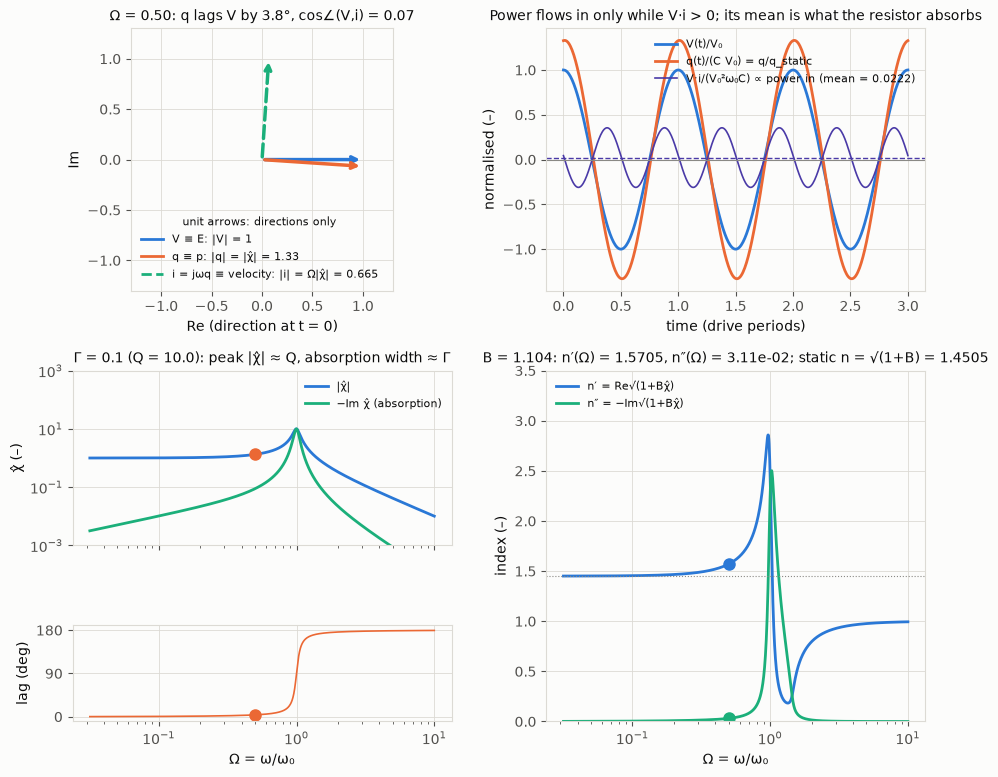

In [2]:
Om_grid = np.logspace(-1.5, 1.0, 1200)
tt = np.linspace(0, 3, 400)

def show_oscillator(Gamma=0.1, Omega=0.5, B=1.104):
    ch = chi_hat(Omega, Gamma); lag = np.radians(phase_lag_deg(Omega, Gamma))
    fig = plt.figure(figsize=(11, 9))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.5, 1.0, 0.55], hspace=0.45, wspace=0.25)
    # phasors: unit arrows (directions only), true lengths in the legend -- |q| spans 1e-2..1e3 over the sliders
    ax = fig.add_subplot(gs[0, 0]); A = abs(ch)
    for ang, col, ls in [(0.0, SERIES[0], "-"), (-lag, SERIES[1], "-"), (-lag + np.pi/2, SERIES[2], "--")]:
        ax.annotate("", xy=(np.cos(ang), np.sin(ang)), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=col, lw=2.5, ls=ls))
    ax.plot([], [], color=SERIES[0], label="V ≡ E: |V| = 1"); ax.plot([], [], color=SERIES[1], label=f"q ≡ p: |q| = |χ̂| = {A:.3g}")
    ax.plot([], [], color=SERIES[2], ls="--", label=f"i = jωq ≡ velocity: |i| = Ω|χ̂| = {Omega*A:.3g}")
    ax.legend(fontsize=8, loc="lower left", title="unit arrows: directions only", title_fontsize=8)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")
    ax.set_title(f"Ω = {Omega:.2f}: q lags V by {np.degrees(lag):.1f}°, cos∠(V,i) = {np.cos(lag-np.pi/2):.2f}", fontsize=10)
    ax.set_xlabel("Re (direction at t = 0)"); ax.set_ylabel("Im")
    # time traces (true amplitudes, axis autoscaled)
    ax = fig.add_subplot(gs[0, 1])
    v = np.cos(2*np.pi*tt); q = A*np.cos(2*np.pi*tt - lag); i = A*Omega*np.cos(2*np.pi*tt - lag + np.pi/2)
    ax.plot(tt, v, color=SERIES[0], label="V(t)/V₀"); ax.plot(tt, q, color=SERIES[1], label="q(t)/(C V₀) = q/q_static")
    ax.plot(tt, v*i, color=SERIES[3], lw=1.2, label="V·i/(V₀²ω₀C) ∝ power in (mean = %.3g)" % np.mean(v*i))
    ax.axhline(np.mean(v*i), color=SERIES[3], lw=1, ls="--")
    ax.axhline(0, color=PALETTE["muted"], lw=0.8); ax.set_xlabel("time (drive periods)"); ax.set_ylabel("normalised (–)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title("Power flows in only while V·i > 0; its mean is what the resistor absorbs", fontsize=10)
    # chi(Omega) on top, lag below (stacked, shared x)
    ax = fig.add_subplot(gs[1, 0])
    cg = chi_hat(Om_grid, Gamma)
    ax.loglog(Om_grid, np.abs(cg), color=SERIES[0], label="|χ̂|")
    ax.loglog(Om_grid, np.maximum(-cg.imag, 1e-9), color=SERIES[2], label="−Im χ̂ (absorption)")
    ax.plot([Omega], [A], "o", color=SERIES[1], ms=8)
    ax.set_ylim(1e-3, 1e3); ax.set_ylabel("χ̂ (–)"); ax.legend(fontsize=8, loc="upper right"); ax.tick_params(labelbottom=False)
    ax.set_title(f"Γ = {Gamma:g} (Q = {1/Gamma:.1f}): peak |χ̂| ≈ Q, absorption width ≈ Γ", fontsize=10)
    axl = fig.add_subplot(gs[2, 0], sharex=ax)
    axl.semilogx(Om_grid, phase_lag_deg(Om_grid, Gamma), color=SERIES[1], lw=1.2)
    axl.plot([Omega], [np.degrees(lag)], "o", color=SERIES[1], ms=8)
    axl.set_yticks([0, 90, 180]); axl.set_ylim(-10, 190); axl.set_xlabel("Ω = ω/ω₀"); axl.set_ylabel("lag (deg)")
    # n', n''
    ax = fig.add_subplot(gs[1:, 1])
    n = n_complex_from_chi(B*cg); nn = n_complex_from_chi(B*ch)
    ax.semilogx(Om_grid, n.real, color=SERIES[0], label="n′ = Re√(1+Bχ̂)")
    ax.semilogx(Om_grid, -n.imag, color=SERIES[2], label="n″ = −Im√(1+Bχ̂)")
    ax.plot([Omega], [nn.real], "o", color=SERIES[0], ms=8); ax.plot([Omega], [-nn.imag], "o", color=SERIES[2], ms=8)
    ax.axhline(np.sqrt(1+B), color=PALETTE["muted"], lw=0.8, ls=":")
    ax.set_ylim(0, max(3.5, 1.1*np.max(n.real))); ax.set_xlabel("Ω = ω/ω₀"); ax.set_ylabel("index (–)"); ax.legend(fontsize=8, loc="upper left")
    ax.set_title(f"B = {B:.3f}: n′(Ω) = {nn.real:.4f}, n″(Ω) = {-nn.imag:.2e}; static n = √(1+B) = {np.sqrt(1+B):.4f}", fontsize=10)
    plt.show()

show_oscillator()

In [3]:
interact(show_oscillator,
         Gamma=FloatLogSlider(value=0.1, base=10, min=-3, max=0, step=0.05, description="Γ = 1/Q"),
         Omega=FloatLogSlider(value=0.5, base=10, min=-1.5, max=1, step=0.02, description="Ω = ω/ω₀"),
         B=FloatSlider(value=1.104, min=0.05, max=3.0, step=0.05, description="B = A/ω₀²"));

interactive(children=(FloatLogSlider(value=0.1, description='Γ = 1/Q', max=0.0, min=-3.0, step=0.05), FloatLog…

## 2. Run ngspice from the notebook: the same circuit at several dampings

The cell below writes a netlist for the series RLC with your `f0` and `Q` (L fixed at 100 mH), runs `ngspice -b`, and overlays the SPICE charge-per-volt on the analytic χ̂. Nothing is written to `out/` (temporary directory).

Q =   2: SPICE peak |chi_hat| = 2.07 (expect ~Q = 2); max |chi| error vs analytic = 0.0001 %
Q =  10: SPICE peak |chi_hat| = 10.00 (expect ~Q = 10); max |chi| error vs analytic = 0.0001 %
Q =  50: SPICE peak |chi_hat| = 50.00 (expect ~Q = 50); max |chi| error vs analytic = 0.0006 %


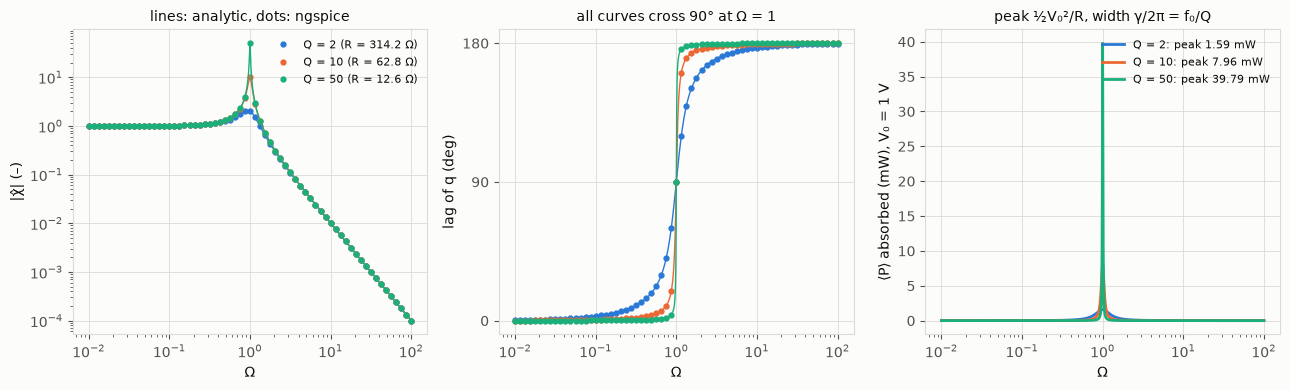

In [4]:
def spice_ac(f0=1000.0, Q=10.0, L=0.1, npts=400):
    L, R, C, w0, gamma = rlc_values(f0, Q, L)
    with tempfile.TemporaryDirectory() as tmp:
        tmp = pathlib.Path(tmp); txt = tmp / "ac.txt"; cir = tmp / "ac.cir"
        cir.write_text(f"* series RLC f0={f0} Q={Q}\nV1 in 0 dc 0 ac 1\nL1 in n1 {L:.6g}\nR1 n1 cap {R:.6g}\nC1 cap 0 {C:.6g}\n"
                       ".control\nset filetype=ascii\nset wr_vecnames\nset wr_singlescale\n"
                       f"ac dec {npts} {f0/100:.6g} {f0*100:.6g}\nlet i_loop = -i(v1)\nwrdata {txt} v(cap) i_loop\nquit\n.endc\n.end\n")
        p = subprocess.run([NGSPICE, "-b", str(cir)], capture_output=True, text=True, cwd=tmp)
        if p.returncode != 0: raise RuntimeError(p.stdout[-1000:] + p.stderr[-1000:])
        d = np.loadtxt(txt, skiprows=1)
    f = d[:, 0]; vcap = d[:, 1] + 1j*d[:, 2]; i = d[:, 3] + 1j*d[:, 4]
    return dict(f=f, Om=f/f0, chi=w0**2*L*C*vcap, P=0.5*np.real(np.conj(i)), L=L, R=R, C=C, gamma=gamma)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
for k, Q in enumerate([2, 10, 50]):
    s = spice_ac(1000.0, Q)
    axs[0].loglog(s["Om"], np.abs(chi_hat(s["Om"], 1/Q)), color=SERIES[k], lw=1)
    axs[0].loglog(s["Om"][::25], np.abs(s["chi"][::25]), "o", ms=3.5, color=SERIES[k], label=f"Q = {Q} (R = {s['R']:.1f} Ω)")
    axs[1].semilogx(s["Om"], phase_lag_deg(s["Om"], 1/Q), color=SERIES[k], lw=1)
    axs[1].semilogx(s["Om"][::25], -np.degrees(np.angle(s["chi"][::25])), "o", ms=3.5, color=SERIES[k])
    axs[2].semilogx(s["Om"], s["P"]*1e3, color=SERIES[k], label=f"Q = {Q}: peak {s['P'].max()*1e3:.2f} mW")
    print(f"Q = {Q:>3}: SPICE peak |chi_hat| = {np.abs(s['chi']).max():.2f} (expect ~Q = {Q}); "
          f"max |chi| error vs analytic = {np.max(np.abs(np.abs(s['chi'])-np.abs(chi_hat(s['Om'],1/Q)))/np.abs(chi_hat(s['Om'],1/Q)))*100:.4f} %")
axs[0].set_xlabel("Ω"); axs[0].set_ylabel("|χ̂| (–)"); axs[0].legend(fontsize=8); axs[0].set_title("lines: analytic, dots: ngspice", fontsize=10)
axs[1].set_xlabel("Ω"); axs[1].set_ylabel("lag of q (deg)"); axs[1].set_yticks([0, 90, 180]); axs[1].set_title("all curves cross 90° at Ω = 1", fontsize=10)
axs[2].set_xlabel("Ω"); axs[2].set_ylabel("⟨P⟩ absorbed (mW), V₀ = 1 V"); axs[2].legend(fontsize=8); axs[2].set_title("peak ½V₀²/R, width γ/2π = f₀/Q", fontsize=10)
fig.tight_layout(); plt.show()

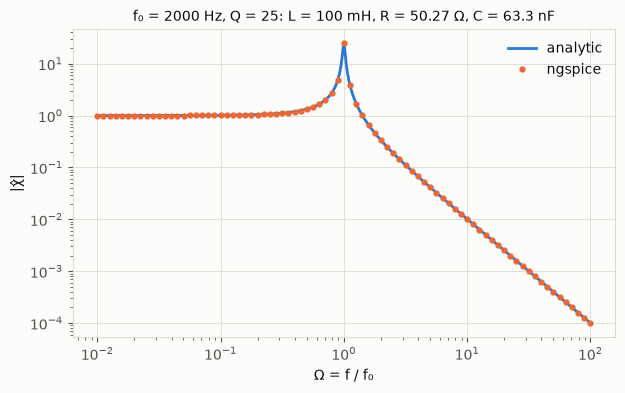

In [5]:
def spice_one(f0=1000.0, Q=10.0):
    s = spice_ac(f0, Q)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.loglog(s["Om"], np.abs(chi_hat(s["Om"], 1/Q)), color=SERIES[0], label="analytic")
    ax.loglog(s["Om"][::20], np.abs(s["chi"][::20]), "o", ms=3.5, color=SERIES[1], label="ngspice")
    ax.set_xlabel("Ω = f / f₀"); ax.set_ylabel("|χ̂|"); ax.legend()
    ax.set_title(f"f₀ = {f0:g} Hz, Q = {Q:g}: L = {s['L']*1e3:.0f} mH, R = {s['R']:.2f} Ω, C = {s['C']*1e9:.1f} nF", fontsize=10)
    plt.show()

# Edit f0 and Q and re-run this cell.  (Deliberately NOT a slider: an ngspice subprocess launched from inside an
# ipywidgets callback deadlocks the headless nbconvert kernel; the analytic sliders above and below are fine.)
spice_one(f0=2000.0, Q=25.0)

## 3. The same χ̂ at optical frequencies: silica's UV resonance and the 1310 nm operating point

Malitson's Sellmeier fit for fused silica is three Lorentz oscillators with the damping dropped (notes §9). Move the wavelength and read off Ω = ω/ω_u, the equivalent frequency in the 1 kHz circuit, and n from the oscillator sum. The slope dn/dλ is split into the UV and IR contributions (notes §10).

λ = 1310 nm: ω = 1.438e+15 rad/s, Ω = ω/ω_u = 0.0680  →  68.0 Hz in the 1 kHz circuit
  n (3-oscillator Lorentz sum, γ→0) = 1.44680;  Sellmeier = 1.44680;  n_g = n − λ dn/dλ = 1.4616
  dn/dλ = -1.1325e-02 /µm  =  UV terms -2.7287e-03  +  IR term -8.5962e-03  (IR share 76 %)


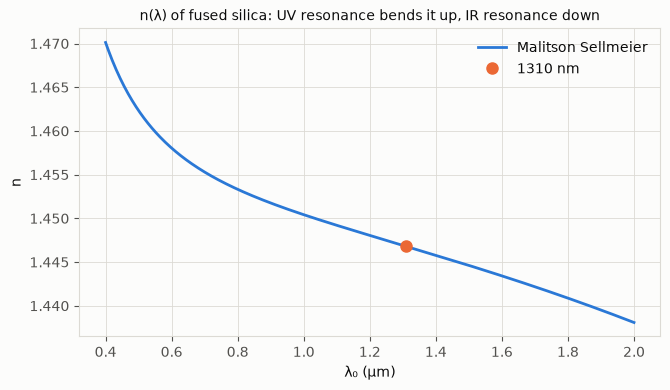

In [6]:
A_i, w_i = malitson_oscillators()
lam_plot = np.linspace(0.4, 2.0, 400)
n_plot = sellmeier_n(lam_plot)

def silica(lam_nm=1310.0):
    lam = lam_nm*1e-3; w = 2*np.pi*C0/(lam*1e-6)
    Om = w/w_u
    n3 = np.sqrt(1 + lorentz_sum(np.array([w]), A_i, w_i, [0, 0, 0])[0].real)
    terms, n = sellmeier_dn_dlam_terms(lam)
    ng = n - lam*terms.sum()
    print(f"λ = {lam_nm:.0f} nm: ω = {w:.3e} rad/s, Ω = ω/ω_u = {Om:.4f}  →  {Om*1000:.1f} Hz in the 1 kHz circuit")
    print(f"  n (3-oscillator Lorentz sum, γ→0) = {n3:.5f};  Sellmeier = {n:.5f};  n_g = n − λ dn/dλ = {ng:.4f}")
    print(f"  dn/dλ = {terms.sum():.4e} /µm  =  UV terms {terms[:2].sum():.4e}  +  IR term {terms[2]:.4e}  (IR share {terms[2]/terms.sum()*100:.0f} %)")
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.plot(lam_plot, n_plot, color=SERIES[0], label="Malitson Sellmeier"); ax.plot([lam], [n], "o", color=SERIES[1], ms=8, label=f"{lam_nm:.0f} nm")
    ax.set_xlabel("λ₀ (µm)"); ax.set_ylabel("n"); ax.legend(); ax.set_title("n(λ) of fused silica: UV resonance bends it up, IR resonance down", fontsize=10)
    plt.show()

silica()

In [7]:
interact(silica, lam_nm=FloatSlider(value=1310, min=400, max=2000, step=10, description="λ (nm)"));

interactive(children=(FloatSlider(value=1310.0, description='λ (nm)', max=2000.0, min=400.0, step=10.0), Outpu…

## 4. Capstone: free carriers are the ω₀ → 0 limit

The modulator changes the ring's index by injecting/depleting carriers: the same oscillator with the spring removed (Drude). Slide the carrier density and see Δn (Drude vs the empirical Soref–Bennett fit for electrons at 1.3 µm), the ring shift if the whole mode saw it uniformly (Δλ = λ·Γ_conf·Δn/n_g with Γ_conf = 0.85, n_g = 4.2), and how many kelvin of thermal drift (50 pm/K) that equals. The reference modulator swings 50 pm/V × 1.3 V = 65 pm.

In [8]:
def carriers(log10_dN=17.0):
    dN = 10**log10_dN
    dn_D, npp_D, da_D = drude_silicon(dN, REF.lambda_nm*1e-9, REF.n_si, 0.26*M_E, 2.0e-13)
    dn_S, da_S = soref_bennett_1310(dN)
    dlam = REF.lambda_nm*1e-9*REF.confinement*dn_S/REF.ng
    print(f"ΔN = {dN:.2e} cm⁻³ electrons at 1310 nm")
    print(f"  Δn: Drude {dn_D:.3e}, Soref–Bennett {dn_S:.3e}   |   Δα: Drude {da_D:.3f} /cm, Soref–Bennett {da_S:.2f} /cm ({da_S*4.343:.1f} dB/cm)")
    print(f"  ring shift (uniform, Γ_conf = {REF.confinement}): {dlam*1e12:+.1f} pm = {dlam*1e12/REF.dlambda_dT_pm_per_K:+.2f} K of thermal drift; "
          f"= {abs(dlam*1e12)/REF.fwhm_pm*100:.1f} % of the {REF.fwhm_pm:.0f} pm FWHM")

carriers(17.0)
interact(carriers, log10_dN=FloatSlider(value=17.0, min=16.0, max=19.0, step=0.1, description="log10 ΔN"));

ΔN = 1.00e+17 cm⁻³ electrons at 1310 nm
  Δn: Drude -8.458e-05, Soref–Bennett -6.200e-05   |   Δα: Drude 0.028 /cm, Soref–Bennett 0.60 /cm (2.6 dB/cm)
  ring shift (uniform, Γ_conf = 0.85): -16.4 pm = -0.33 K of thermal drift; = 4.4 % of the 374 pm FWHM


interactive(children=(FloatSlider(value=17.0, description='log10 ΔN', max=19.0, min=16.0), Output()), _dom_cla…